# Step 4: Final Optimized Cross-Task Evaluation

This version removes all manual re-implementations of sliding windows and metric math. It treats the `eomt` repository as a library, calling the same internal methods used by the training CLI.

In [ ]:
# @title
!pip install lightning > /dev/null

In [ ]:
# @title
!pip install gitignore_parser > /dev/null

In [ ]:
# @title
!pip install -U 'jsonargparse[signatures]>=4.27.7' >/dev/null

In [ ]:
# @title
#!ln -s /content/drive/MyDrive/FundGitHubProject ProjectFolder

In [ ]:
from google.colab import drive
import os
import sys
import yaml
import torch
import importlib
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from lightning import seed_everything

# 1. Environment Configuration
drive.mount('/content/drive')
project_root = '/content/drive/MyDrive/FundGitHubProject'
eomt_folder = project_root + '/eomt'

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if eomt_folder not in sys.path:
    sys.path.insert(0, eomt_folder) # Insert at the beginning to override pre-installed 'datasets'

from eval.iouEval import iouEval

seed_everything(0, verbose=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Mounted at /content/drive
Active Device: cuda


In [ ]:
import os

# Create an alias in the root directory, avoid annoying nesting in the file menu!
# Acts oon the namespace so the shortcut can also be used in the command lines!
source = '/content/drive/MyDrive/FundGitHubProject'
destination = '/ProjectFolder'

if not os.path.exists(destination):
    os.symlink(source, destination)
    print("Shortcut created! Refresh the Files menu on the left to see '/ProjectFolder'.")
else:
    print("Shortcut already exists!")

Shortcut created! Refresh the Files menu on the left to see '/ProjectFolder'.


In [ ]:
import sys
import os
import importlib
import yaml
import torch

def load_project_model(config_path, checkpoint_path):
    with open(config_path, "r") as f: cfg = yaml.safe_load(f)

    # A. Setup Data (Extract metadata like img_size)
    d_mod, d_cls = cfg["data"]["class_path"].rsplit(".", 1)
    if not d_mod.startswith("eomt."):
        d_mod = f"eomt.{d_mod}"
    dm = getattr(importlib.import_module(d_mod), d_cls)(path="eomt/data", batch_size=1, num_workers=0, **cfg["data"].get("init_args", {}))

    # B. Setup Model (Recursive build of Encoder -> Network -> LightningModule)
    m_mod, m_cls = cfg["model"]["class_path"].rsplit(".", 1)
    if not m_mod.startswith("eomt."):
        m_mod = f"eomt.{m_mod}"
    net_args = cfg["model"]["init_args"]["network"]

    from eomt.models.vit import ViT
    from eomt.models.eomt import EoMT

    encoder = ViT(img_size=dm.img_size, **net_args["init_args"]["encoder"]["init_args"])
    network = EoMT(encoder=encoder, num_classes=dm.num_classes, **{k:v for k,v in net_args["init_args"].items() if k != "encoder"})

    # Extract extra dataset-specific arguments safely from the yaml config!
    def find_key(d, target_key):
        if isinstance(d, dict):
            if target_key in d:
                return d[target_key]
            for k, v in d.items():
                res = find_key(v, target_key)
                if res is not None:
                    return res
        return None

    extra_args = {}
    sc_from_cfg = find_key(cfg, "stuff_classes")
    if sc_from_cfg is not None:
        extra_args["stuff_classes"] = sc_from_cfg
    elif hasattr(dm, "stuff_classes"):
        extra_args["stuff_classes"] = dm.stuff_classes

    model = getattr(importlib.import_module(m_mod), m_cls)(
        network=network, img_size=dm.img_size, num_classes=dm.num_classes,
        **extra_args,
        **{k:v for k,v in cfg["model"]["init_args"].items() if k != "network"}
    )

    # C. State Dict Injection
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    model.load_state_dict(ckpt.get("state_dict", ckpt), strict=False)
    return model.to(device).eval(), dm

# Updated the checkpoint path to look for the .bin format!
model_cs, dm_cs = load_project_model("eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "eomt/eomt_weights/eomt_cityscapes.bin")
model_coco, _ = load_project_model("eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml", "eomt/eomt_weights/eomt_coco.bin")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


## 3. The Cityscape Eomt model

In [ ]:
# @title
#import torch
#
## Wrap raw weights into a valid PyTorch Lightning checkpoint format
#bin_path = "eomt/eomt_weights/eomt_cityscapes.bin"
#ckpt_path = "eomt/eomt_weights/eomt_cityscapes.ckpt"
#
#raw_ckpt = torch.load(bin_path, map_location="cpu")
#pl_ckpt = {
#    "state_dict": raw_ckpt.get("state_dict", raw_ckpt),
#    "pytorch-lightning_version": "2.0.0"  # Mock version to satisfy the CLI
#}
#torch.save(pl_ckpt, ckpt_path)
#
## Run the validate subcommand using the new .ckpt file
#!python eomt/main.py validate \t_path} \
#  --data.init_args.path eomt/data \
#  --data.init_args.batch_size 1 \
#  --data.init_args.num_workers 2

In [ ]:
#!wget https://raw.githubusercontent.com/cocodataset/panopticapi/master/panoptic_coco_categories.json -P /content/drive/MyDrive/FundGitHubProject/eomt/data

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from eval.iouEval import iouEval
import os
import json


# 1. Load the pre-computed numerical JSON mapping directly
mapping_path = os.path.join(project_root, 'coco-classes-mapping-master/coco_to_cs.json')
with open(mapping_path, 'r') as f:
    numerical_map = json.load(f)

# 2. Create the O(1) Vectorized Lookup Table directly on the GPU
# Initialize with 19 (the 'ignore' class for Cityscapes)
lookup_table = torch.full((256,), 19, dtype=torch.long, device=device)
for model_idx_str, cs_id in numerical_map.items():
    lookup_table[int(model_idx_str)] = cs_id

evaluator = iouEval(20) # 19 classes + 1 ignore bucket # Is this 20 or 19

dm_cs.setup("validate") # Explicitly call setup for the validation stage
for batch in tqdm(dm_cs.val_dataloader(), desc="Evaluating Mapped COCO"):
    imgs, targets = batch
    gt = model_cs.to_per_pixel_targets_semantic(targets, 19)[0].to(device)

    with torch.no_grad():
        # Predict using COCO model
        tx = model_coco.resize_and_pad_imgs_instance_panoptic([imgs[0].to(device)])
        mp, cp = model_coco(tx)
        mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(
            F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"),
            [imgs[0].shape[-2:]]
        )
        pred = model_coco.to_per_pixel_preds_panoptic(
            mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8
        )[0][..., 0]

        # 3. Bridge: Apply the vectorized lookup directly!
        mapped_pred = lookup_table[pred.long()]

        # Eval
        evaluator.addBatch(mapped_pred.unsqueeze(0).unsqueeze(0), gt.unsqueeze(0).unsqueeze(0))

_, ious = evaluator.getIoU()
print(f"\nUpdated Zero-Shot COCO mIoU on Cityscapes: {ious[:19].mean()*100:.2f}%")

Evaluating Mapped COCO: 100%|██████████| 500/500 [03:16<00:00,  2.54it/s]


Updated Zero-Shot COCO mIoU on Cityscapes: 48.80%


### 4. Fair Comparison: Zero-Shot vs Supervised
To fulfill the project requirements for Phase 4, we need a consistent evaluation strategy for a fair comparison. We already got an overall mIoU of ~81.7% from the CLI, but to generate the comparison figures, we will run the Cityscapes model through the exact same `iouEval` pipeline as our zero-shot model to extract the per-class arrays.

In [ ]:
evaluator_cs = iouEval(20) # 19 classes + 1 ignore bucket

for batch in tqdm(dm_cs.val_dataloader(), desc="Evaluating Cityscapes Model"):
    imgs, targets = batch
    gt = model_cs.to_per_pixel_targets_semantic(targets, 19)[0].to(device)

    with torch.no_grad():
        crops, origins = model_cs.window_imgs_semantic([imgs[0].to(device)])
        m_l, c_l = model_cs(crops)
        m_l = F.interpolate(m_l[-1], model_cs.img_size, mode="bilinear")
        crop_logits = model_cs.to_per_pixel_logits_semantic(m_l, c_l[-1])
        pred_cs = model_cs.revert_window_logits_semantic(crop_logits, origins, [imgs[0].shape[-2:]])[0].argmax(0)

        evaluator_cs.addBatch(pred_cs.unsqueeze(0).unsqueeze(0), gt.unsqueeze(0).unsqueeze(0))

_, ious_cs = evaluator_cs.getIoU()
print(f"\nCityscapes Supervised mIoU: {ious_cs[:19].mean()*100:.2f}%")

Evaluating Cityscapes Model: 100%|██████████| 500/500 [03:51<00:00,  2.16it/s]


Cityscapes Supervised mIoU: 81.68%


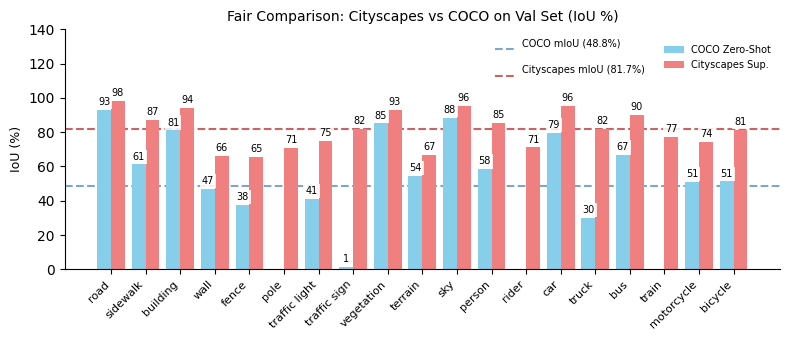

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cityscapes classes names (0-18)
class_names = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole', 'traffic light',
    'traffic sign', 'vegetation', 'terrain', 'sky', 'person', 'rider',
    'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

# Extract the class IoUs from both evaluators and convert to percentages
_, ious = evaluator.getIoU()
ious_np = ious[:19].cpu().numpy() * 100

ious_cs_np = ious_cs[:19].cpu().numpy() * 100

# Calculate overall mIoU
miou_coco = ious_np.mean()
miou_cs = ious_cs_np.mean()

# We removed the manual 'mIoU' plot extension since we now use horizontal lines
x = np.arange(len(class_names))
width = 0.4

# Ultra-compact figsize specifically tailored for a 5-page report
fig, ax = plt.subplots(figsize=(8, 3.5))

# DATA-TO-INK: Removed 'edgecolor' to reduce non-data ink
rects1 = ax.bar(x - width/2, ious_np, width, label='COCO Zero-Shot', color='skyblue', zorder=2)
rects2 = ax.bar(x + width/2, ious_cs_np, width, label='Cityscapes Sup.', color='lightcoral', zorder=2)

# Added horizontal dashed lines as requested by the colleague
ax.axhline(y=miou_coco, color='steelblue', linestyle='--', linewidth=1.5, zorder=1, alpha=0.7, label=f'COCO mIoU ({miou_coco:.1f}%)\n')
ax.axhline(y=miou_cs, color='firebrick', linestyle='--', linewidth=1.5, zorder=1, alpha=0.7, label=f'Cityscapes mIoU ({miou_cs:.1f}%)\n')

# Title and axis labels
ax.set_title('Fair Comparison: Cityscapes vs COCO on Val Set (IoU %)', fontsize=10)
ax.set_ylabel('IoU (%)', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)

# Legend configuration
ax.legend(fontsize=7, ncol=2, loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='none')
ax.set_ylim(0, 140)

# Enable y-axis ticks and left spine, but disable grid
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)

# Function to attach a text label above each bar with a "repel" effect
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Only label if > 0 to avoid cluttering at the baseline
        if height > 0.1:
            ax.annotate(f'{height:.0f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=7,
                        bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.85)) # The bbox masks the lines behind it

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.savefig('comparison_histogram.png', dpi=300)
plt.show()


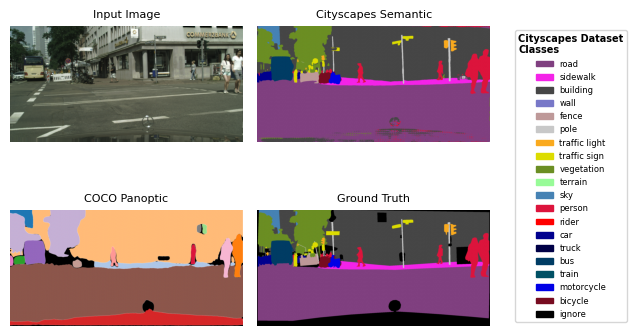

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import torch
import torch.nn.functional as F
import numpy as np

# Select a single distinct sample index for the 2x2 grid
idx = 235

# Define standard Cityscapes colors (normalized to 0-1) + Black for 'ignore' (class 19)
# Tweaked 'wall' (index 3) to be more bluish-purple and 'pole' (index 5) to be a lighter grey for better contrast
cs_colors = np.array([
    [128, 64, 128], [244, 35, 232], [70, 70, 70], [120, 120, 200],
    [190, 153, 153], [200, 200, 200], [250, 170, 30], [220, 220, 0],
    [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
    [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100],
    [0, 80, 100], [0, 0, 230], [119, 11, 32], [0, 0, 0]
]) / 255.0
cs_cmap = ListedColormap(cs_colors)

# Extended class names including ignore
extended_class_names = class_names + ['ignore']

# Ultra-compact figsize for a dense 5-page report
fig, axes = plt.subplots(2, 2, figsize=(6, 4))

with torch.no_grad():
    img, target = dm_cs.cityscapes_val_dataset[idx]
    orig_size = img.shape[-2:]

    # Extract Ground Truth (class 19 is the ignore index here)
    gt = model_cs.to_per_pixel_targets_semantic([target], 19)[0].cpu().numpy()

    # 1. Cityscapes Semantic (Sliding Window)
    crops, origins = model_cs.window_imgs_semantic([img])
    m_l, c_l = model_cs(crops.to(device))
    m_l = F.interpolate(m_l[-1], model_cs.img_size, mode="bilinear")
    crop_logits = model_cs.to_per_pixel_logits_semantic(m_l, c_l[-1])
    pred_cs = model_cs.revert_window_logits_semantic(crop_logits, origins, [orig_size])[0].argmax(0)

    # 2. COCO Panoptic
    tx = model_coco.resize_and_pad_imgs_instance_panoptic([img.to(device)])
    mp, cp = model_coco(tx)
    mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(
        F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"),
        [orig_size]
    )
    pred_coco = model_coco.to_per_pixel_preds_panoptic(
        mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8
    )[0]

    coco_semantic = pred_coco[..., 0].long()
    panoptic_instances = pred_coco[..., 1].cpu().numpy()

    # Map COCO semantic to Cityscapes classes using the lookup_table from global kernel state
    mapped_semantic = lookup_table[coco_semantic].cpu().numpy()

    # Extract boundaries for the panoptic instance map
    shifted_up = np.roll(panoptic_instances, -1, axis=0)
    shifted_left = np.roll(panoptic_instances, -1, axis=1)
    boundaries = (panoptic_instances != shifted_up) | (panoptic_instances != shifted_left)

    # Create semantic-aware colors for panoptic instances
    base_colors = cs_colors[mapped_semantic]

    # Initialize RGB map with base colors for 'stuff' classes
    panoptic_viz_rgb = base_colors.copy()

    # Apply distinct colors to 'thing' instances
    ignore_mask = mapped_semantic == 19
    instance_mask = (panoptic_instances > 0) & ~ignore_mask
    unique_instances = np.unique(panoptic_instances[instance_mask])

    # Use a high-contrast colormap for instances
    inst_cmap = plt.get_cmap('tab20')
    np.random.seed(42) # For reproducible colors per instance
    np.random.shuffle(unique_instances)

    for i, inst_id in enumerate(unique_instances):
        inst_pixels = (panoptic_instances == inst_id) & ~ignore_mask
        panoptic_viz_rgb[inst_pixels] = inst_cmap(i % 20)[:3]

    # Add alpha channel (fully opaque)
    panoptic_viz = np.concatenate([panoptic_viz_rgb, np.ones_like(panoptic_instances)[..., np.newaxis]], axis=-1)

    # Use White boundaries instead of black! This sharply separates dark instances (like people in red)
    valid_boundaries = boundaries & ~ignore_mask
    panoptic_viz[valid_boundaries] = [1, 1, 1, 1]

    # Force ignore regions to be uniformly black
    panoptic_viz[ignore_mask] = [0, 0, 0, 1]

    t_font = 8 # Even smaller title font for compact view

    # Plot 1: Input Image
    axes[0, 0].imshow(img.permute(1, 2, 0).numpy())
    axes[0, 0].set_title("Input Image", fontsize=t_font)
    axes[0, 0].axis("off")

    # Plot 2: Cityscapes Semantic Map
    axes[0, 1].imshow(pred_cs.cpu().numpy(), cmap=cs_cmap, vmin=0, vmax=19)
    axes[0, 1].set_title("Cityscapes Semantic", fontsize=t_font)
    axes[0, 1].axis("off")

    # Plot 3: COCO Panoptic Map (Instances + Boundaries)
    axes[1, 0].imshow(panoptic_viz)
    axes[1, 0].set_title("COCO Panoptic", fontsize=t_font)
    axes[1, 0].axis("off")

    # Plot 4: Ground Truth
    axes[1, 1].imshow(gt, cmap=cs_cmap, vmin=0, vmax=19)
    axes[1, 1].set_title("Ground Truth", fontsize=t_font)
    axes[1, 1].axis("off")

# Create Legend for Cityscapes Classes
patches = [mpatches.Patch(color=cs_colors[i], label=extended_class_names[i]) for i in range(len(extended_class_names))]

# Attach legend at a specific clear coordinate with a smaller font and an explicit title
leg = fig.legend(
    handles=patches,
    loc='center left',
    bbox_to_anchor=(0.86, 0.5),
    fontsize=6,
    ncol=1,
    title="Cityscapes Dataset\nClasses" # Explicitly define the dataset
)
leg.get_title().set_fontsize(7)
leg.get_title().set_fontweight('bold')

# Confine the subplots to the left 85% of the figure, explicitly preserving the right 15% for the legend
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('predictions.png', bbox_inches='tight', dpi=300) # Maintain high DPI for crisp scaling
plt.show()


## Visualize predictions

In [ ]:
import matplotlib.colors as mcolors
import numpy as np

def colorize_semantic(class_map):
    """Colour a (H, W) Cityscapes-train-ID map with the official palette.
    IGNORE pixels stay black."""
    rgb = np.zeros((*class_map.shape, 3), dtype=np.float32)
    for c in range(19):
        rgb[class_map == c] = cs_colors[c]
    return rgb

def colorize_panoptic(class_map, segment_map):
    """Colour a panoptic map so each segment gets a distinct colour.
    Things -> vivid colours; stuff -> muted colours; void -> black."""
    rgb = np.zeros((*segment_map.shape, 3), dtype=np.float32)
    rng = np.random.default_rng(seed=42)                 # reproducible colours

    stuff_classes = getattr(model_coco, 'stuff_classes', [])
    for sid in np.unique(segment_map):
        if sid <= 0:                                      # void
            continue
        seg = segment_map == sid
        # Representative COCO class of this segment (majority vote).
        coco_cls = int(np.bincount(class_map[seg]).argmax())
        is_stuff = coco_cls in stuff_classes
        sat, val = (0.35, 0.65) if is_stuff else (0.85, 0.95)
        r, g, b = mcolors.hsv_to_rgb([rng.uniform(0, 1), sat, val])
        rgb[seg] = [r, g, b]
    return rgb


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F

def visualize_sample(idx, save_path=None):
    """Five-panel comparison for one validation image."""
    img, target = val_dataset[idx]
    orig_size = img.shape[-2:]
    img_path = f"sample_{idx}.png"
    print(f'Visualising: {img_path}')

    with torch.no_grad():
        gt_cs = model_cs.to_per_pixel_targets_semantic([target], 19)[0].cpu().numpy()

        # 1. Cityscapes Semantic
        crops, origins = model_cs.window_imgs_semantic([img])
        m_l, c_l = model_cs(crops.to(device))
        m_l = F.interpolate(m_l[-1], model_cs.img_size, mode="bilinear")
        crop_logits = model_cs.to_per_pixel_logits_semantic(m_l, c_l[-1])
        pred_cs = model_cs.revert_window_logits_semantic(crop_logits, origins, [orig_size])[0].argmax(0).cpu().numpy()

        # 2. COCO Panoptic
        tx = model_coco.resize_and_pad_imgs_instance_panoptic([img.to(device)])
        mp, cp = model_coco(tx)
        mp = model_coco.revert_resize_and_pad_logits_instance_panoptic(
            F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"),
            [orig_size]
        )
        pred_coco = model_coco.to_per_pixel_preds_panoptic(
            mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8
        )[0]
        coco_semantic = pred_coco[..., 0].long()
        pan_seg = pred_coco[..., 1].cpu().numpy()

        pred_coco_cs = lookup_table[coco_semantic].cpu().numpy()
        pan_class = coco_semantic.cpu().numpy()

    panels = [
        (img.permute(1, 2, 0).numpy(),         'Original image'),
        (colorize_semantic(pred_cs),                 'EoMT-Cityscapes\nsemantic (19 classes)'),
        (colorize_panoptic(pan_class, pan_seg),      'EoMT-COCO\npanoptic (per-instance colours)'),
        (colorize_semantic(pred_coco_cs),            'EoMT-COCO remapped\nsemantic (-> 19 CS classes)'),
        (colorize_semantic(gt_cs),                   'Ground truth\n(19 CS classes)'),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(30, 6))
    fig.suptitle(os.path.basename(img_path), fontsize=12, fontweight='bold')
    for ax, (im, title) in zip(axes, panels):
        ax.imshow(im)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    legend = [mpatches.Patch(color=cs_colors[i], label=extended_class_names[i]) for i in range(19)]
    fig.legend(handles=legend, loc='lower center', ncol=10, fontsize=12, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  saved -> {save_path}')
    plt.show()
    plt.close(fig)


Visualising: sample_0.png
  saved -> /content/drive/MyDrive/FundGitHubProject/viz_sample_0.png


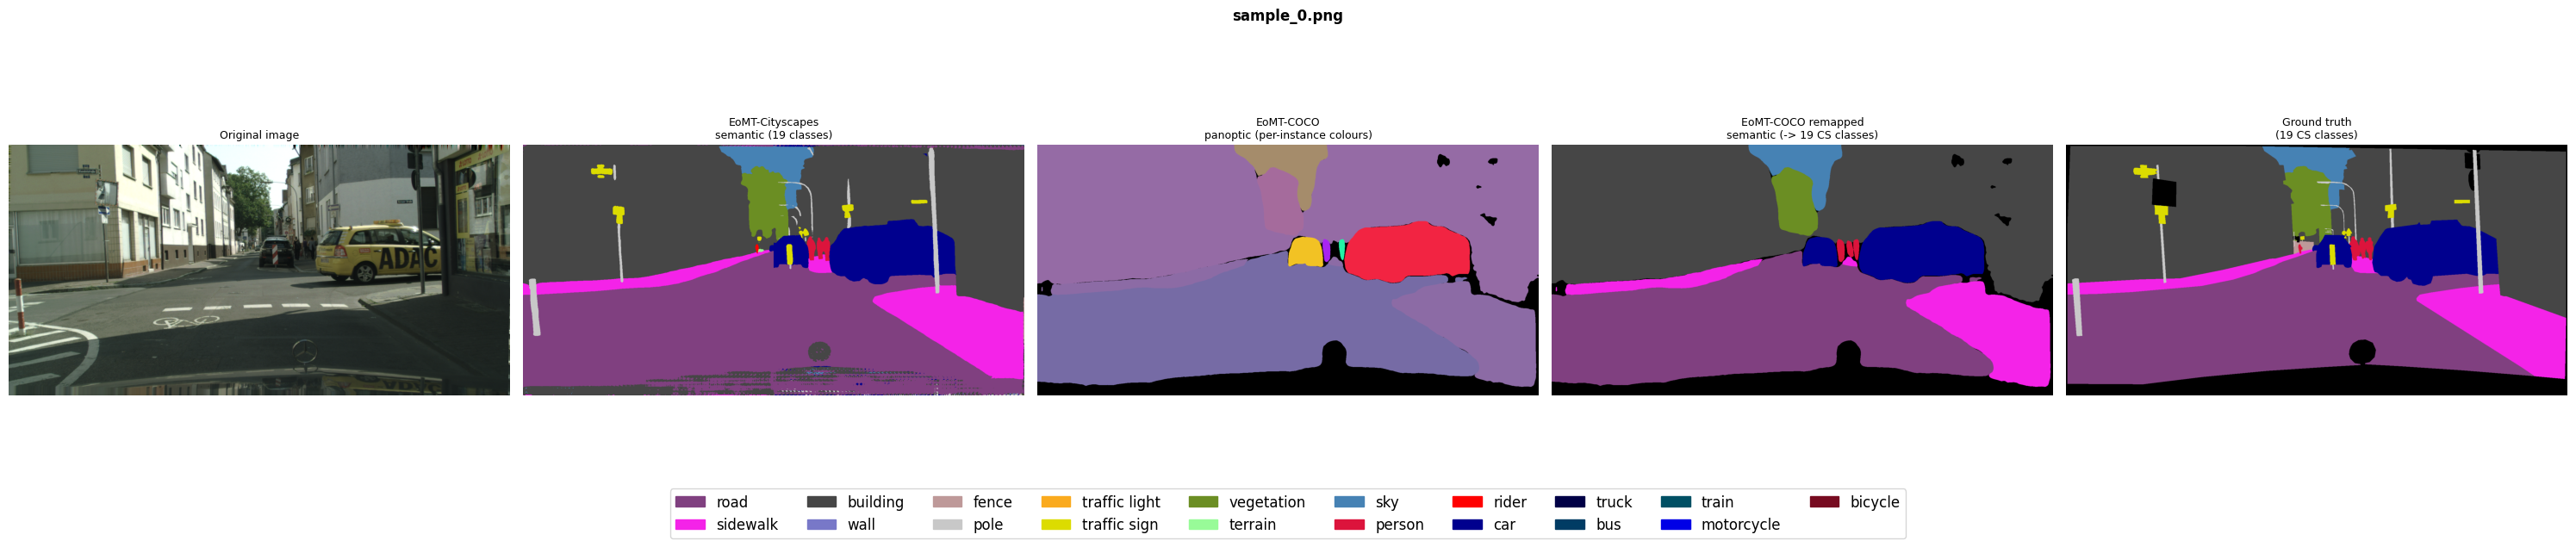

Visualising: sample_100.png
  saved -> /content/drive/MyDrive/FundGitHubProject/viz_sample_1.png


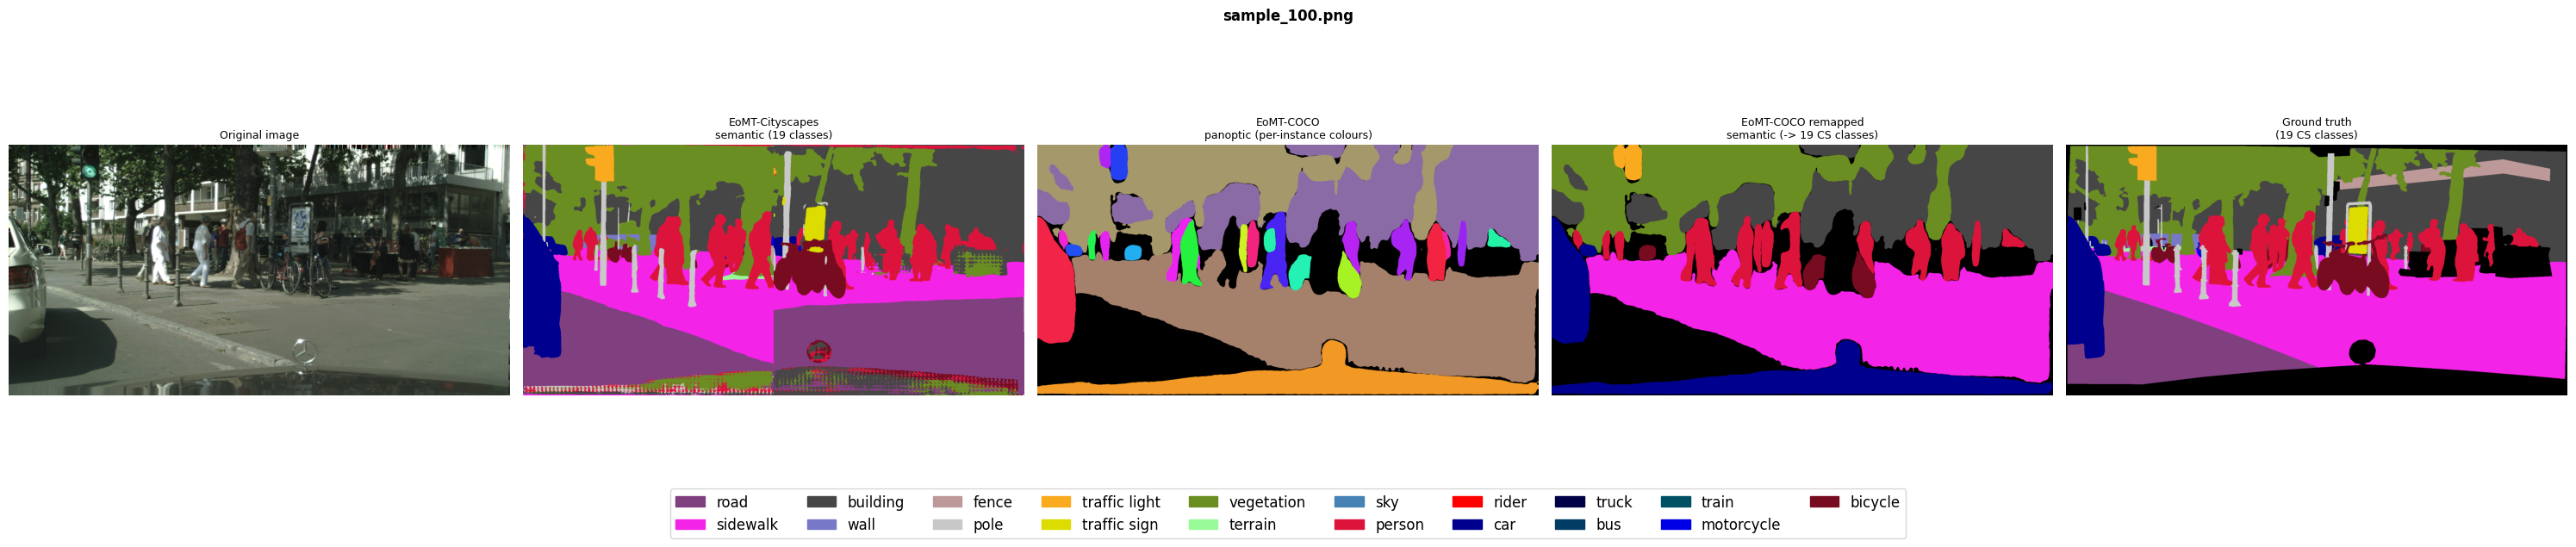

Visualising: sample_166.png
  saved -> /content/drive/MyDrive/FundGitHubProject/viz_sample_2.png


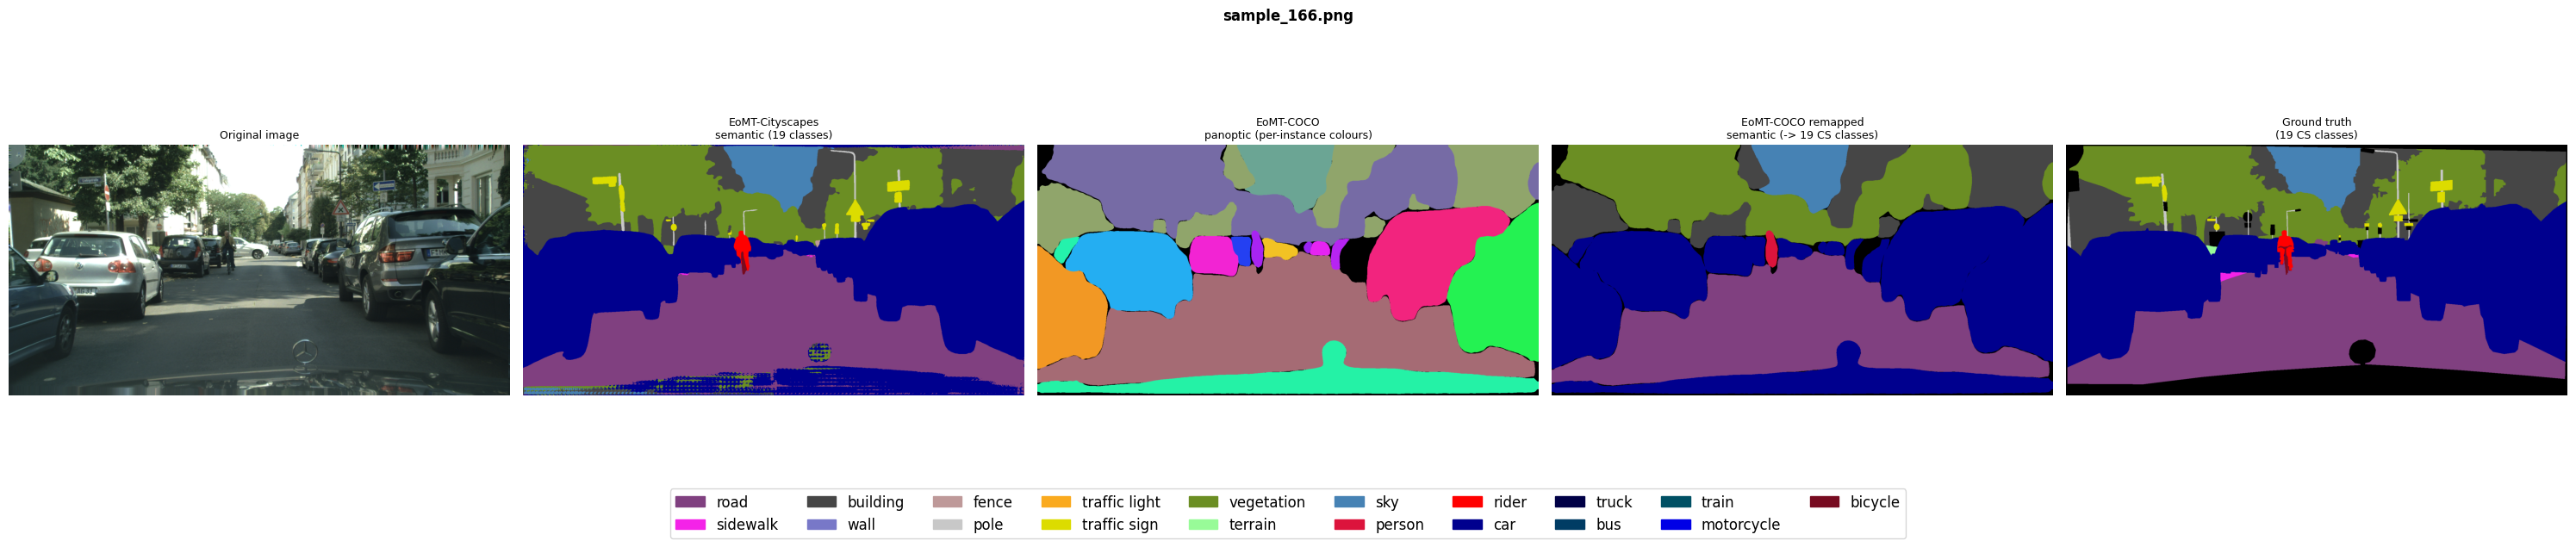

Visualising: sample_250.png
  saved -> /content/drive/MyDrive/FundGitHubProject/viz_sample_3.png


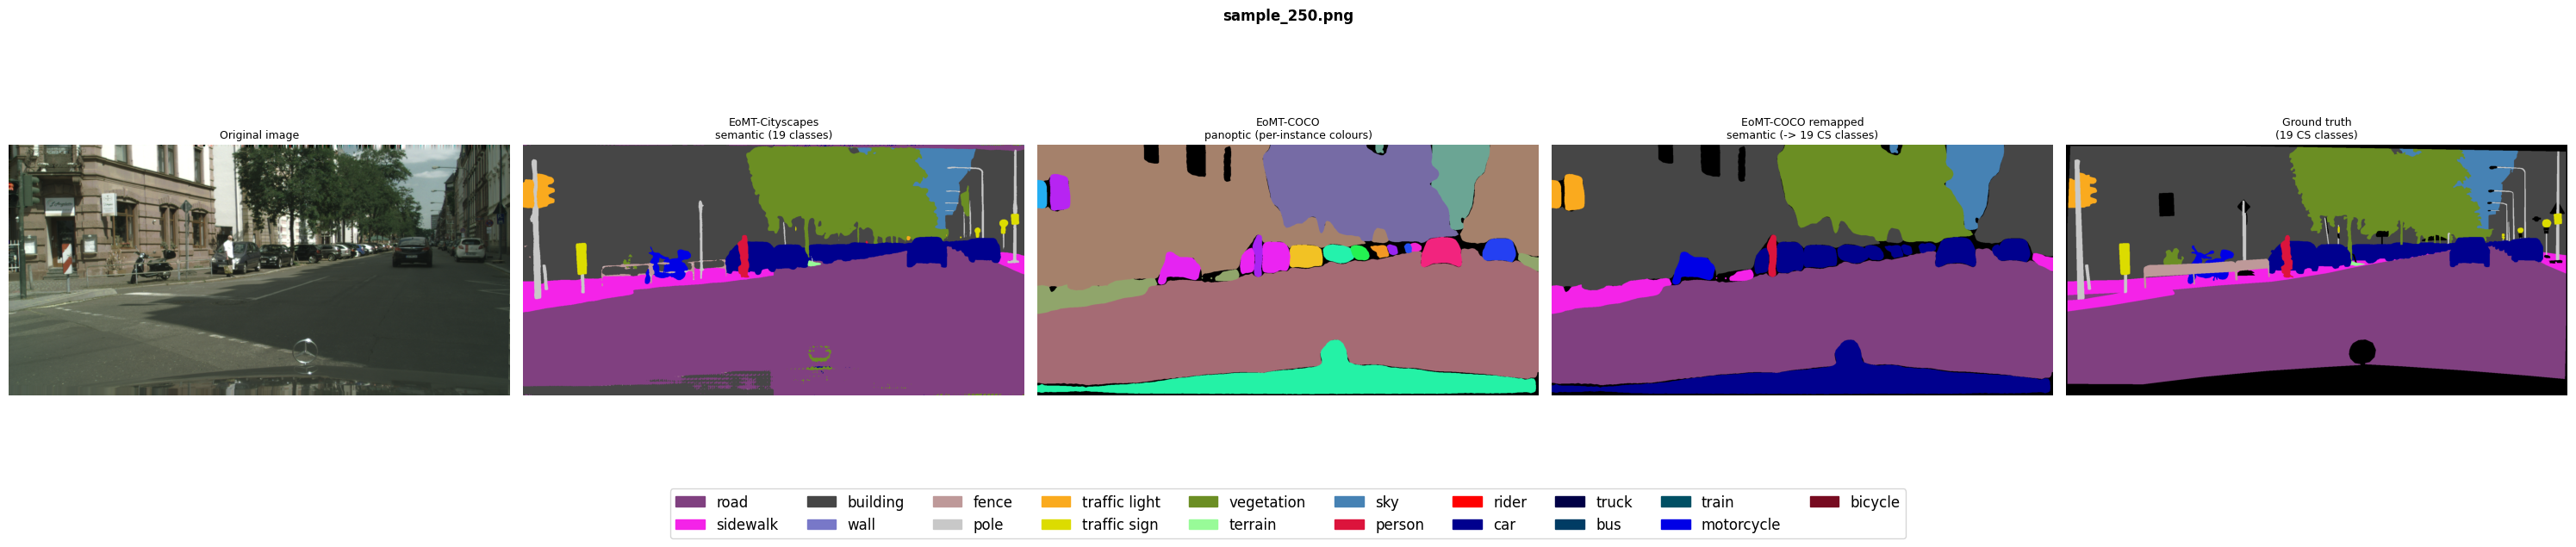

Visualising: sample_332.png
  saved -> /content/drive/MyDrive/FundGitHubProject/viz_sample_4.png


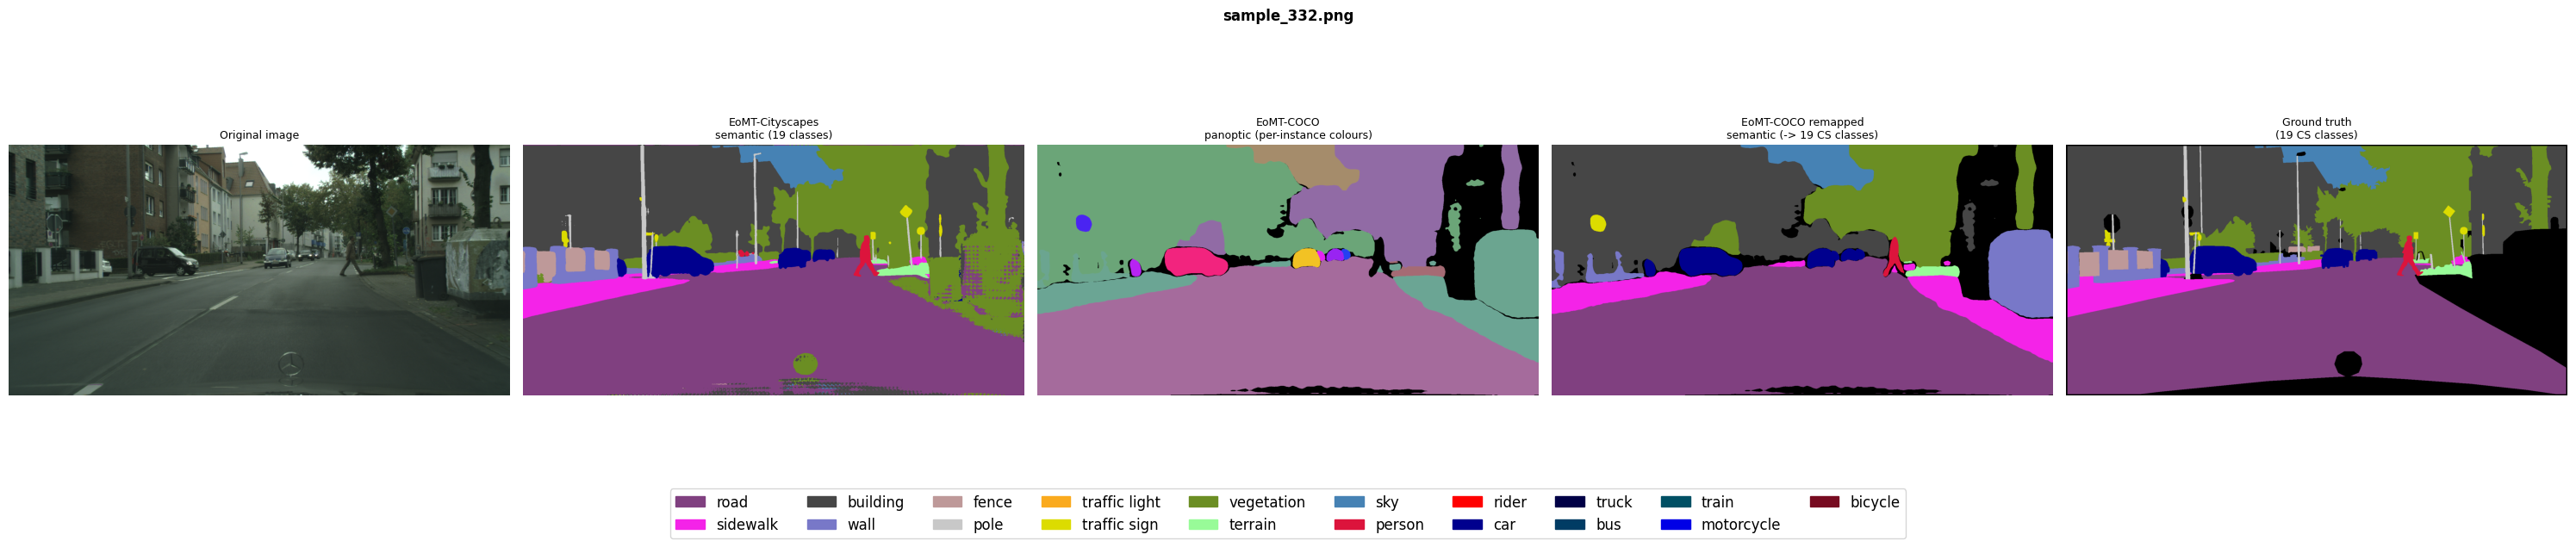

Visualising: sample_499.png
  saved -> /content/drive/MyDrive/FundGitHubProject/viz_sample_5.png


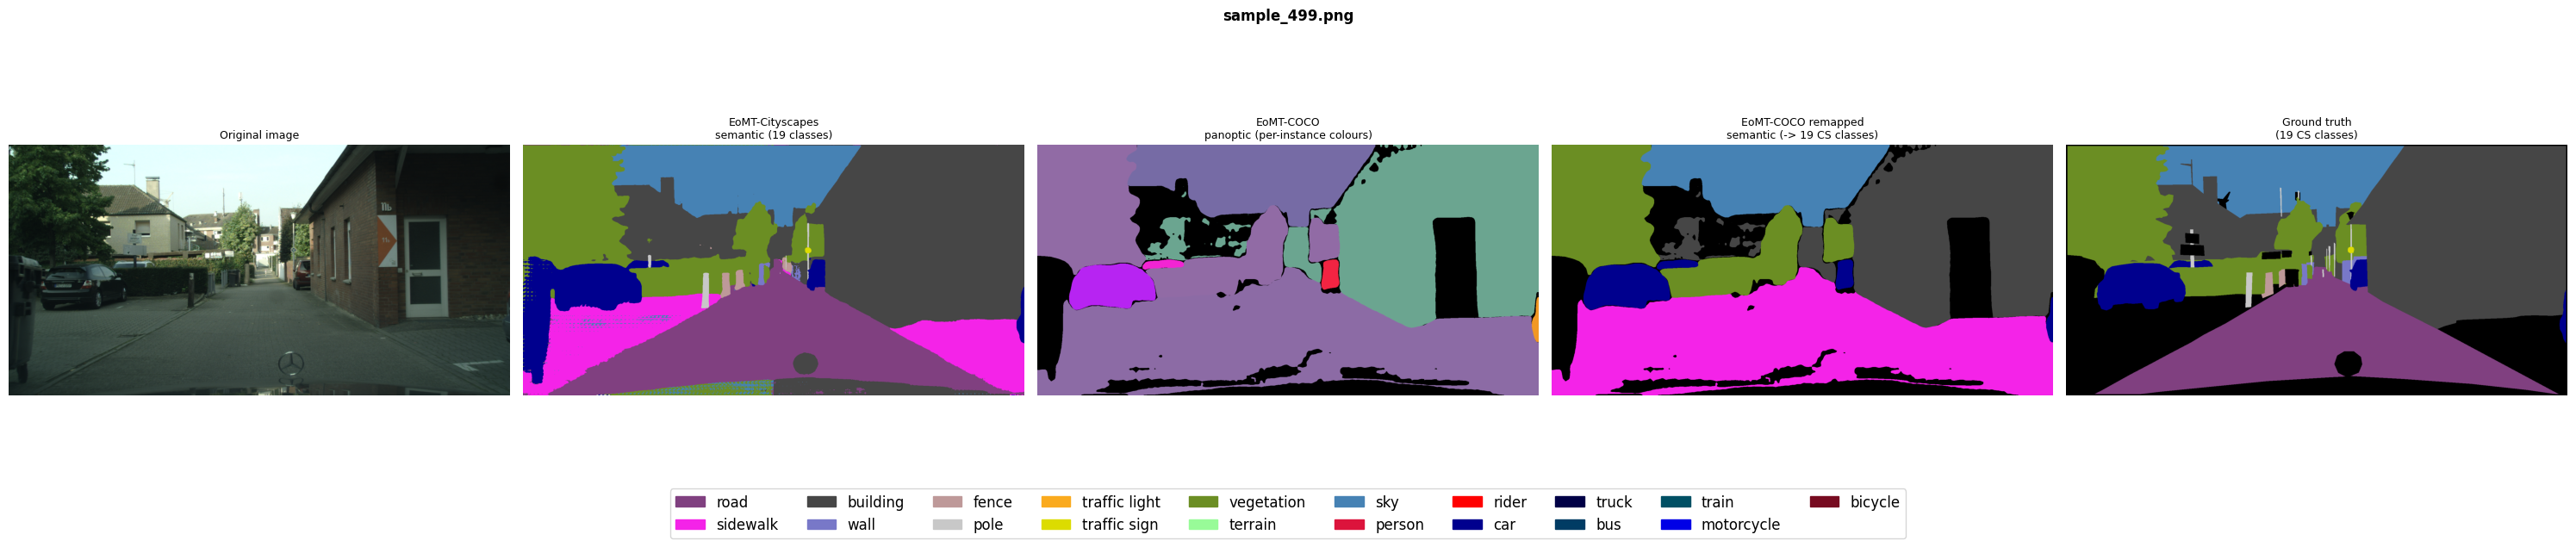

In [ ]:
val_dataset = dm_cs.cityscapes_val_dataset
DRIVE_ROOT = project_root

N = len(val_dataset)
for i, idx in enumerate([0, N // 5, N // 3, N // 2, 2 * (N // 3), N - 1]):
    visualize_sample(idx, save_path=os.path.join(DRIVE_ROOT, f'viz_sample_{i}.png'))
